In [17]:
from pathlib import Path
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 150

SIZE_THRESHOLD = 100_000
RESIZE = (64, 64)
IMG_PATH = Path("./screenshots/gambling/101452.png")

---
## 0. Gambar Original
File: `screenshots/gambling/101452.png` (domain `slotmantapviral.com`)

Size      : (1280, 720)
File size : 842 KB
Mode      : RGB
Array     : (720, 1280, 3), uint8
Range     : 0 - 255


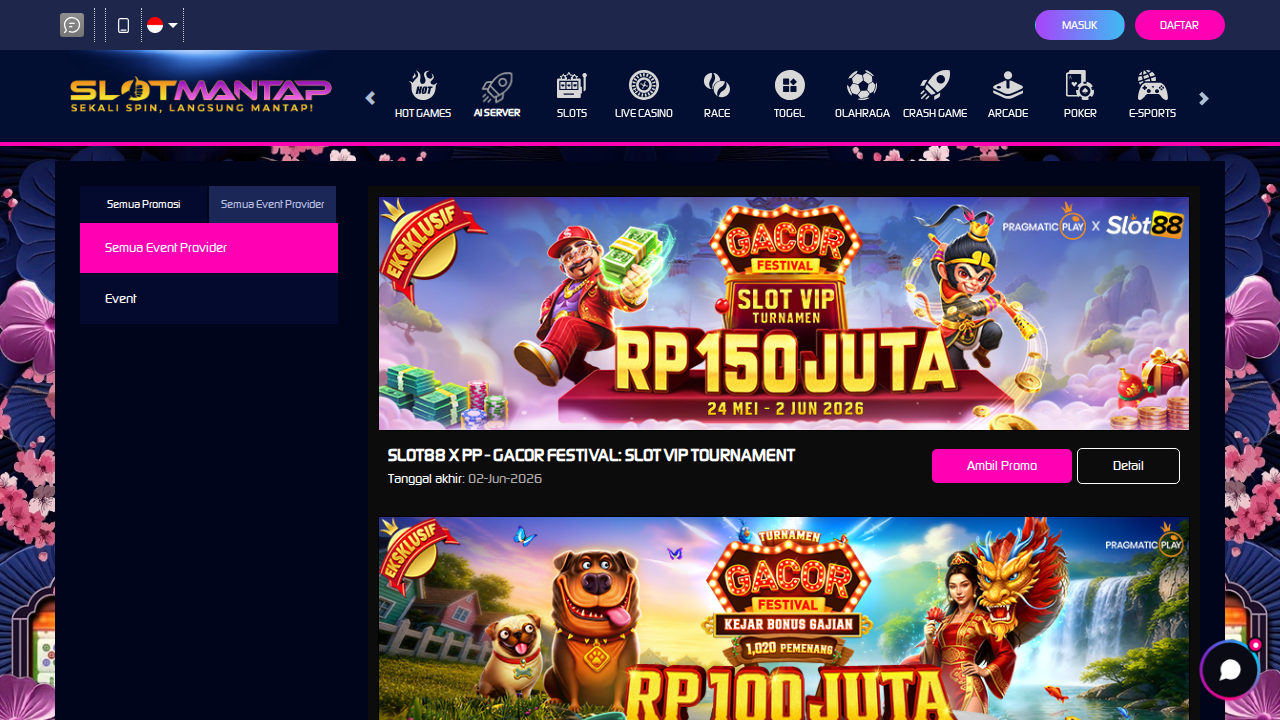

In [18]:
img = Image.open(IMG_PATH)
arr_original = np.array(img)
file_size = IMG_PATH.stat().st_size

print(f"Size      : {img.size}")
print(f"File size : {file_size / 1024:.0f} KB")
print(f"Mode      : {img.mode}")
print(f"Array     : {arr_original.shape}, {arr_original.dtype}")
print(f"Range     : {arr_original.min()} - {arr_original.max()}")

img

---
## 1. Filter Noise
PNG < 100 KB dihapus (noise: blank, partial render, gagal load).

In [19]:
print(f"Size      : {file_size:,} bytes ({file_size / 1024:.0f} KB)")
print(f"Threshold : {SIZE_THRESHOLD:,} bytes (100 KB)")
print(f"Status    : {'Lolos (\u2265100 KB)' if file_size >= SIZE_THRESHOLD else 'NOISE \u2014 DIHAPUS'}")

Size      : 862,410 bytes (842 KB)
Threshold : 100,000 bytes (100 KB)
Status    : Lolos (≥100 KB)


---
## 2. Resize 64x64
`Image.resize((64, 64), Image.LANCZOS)`

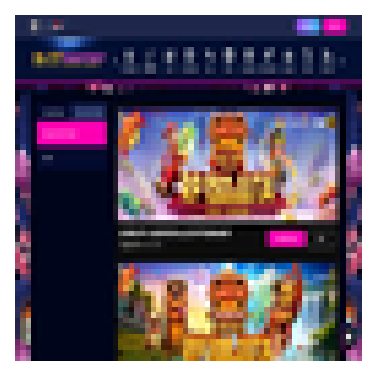

In [20]:
img_resized = img.resize(RESIZE, Image.LANCZOS)
arr_resized = np.array(img_resized)

fig, ax = plt.subplots(figsize=(3, 3))
ax.imshow(img_resized)
ax.axis('off')
plt.show()